In [1]:
# source: https://ti.arc.nasa.gov/tech/dash/groups/pcoe/prognostic-data-repository/
# Aim : To predict RUL (Remaining useful life) and last_15_cycles

In [2]:
import warnings
warnings.filterwarnings("ignore")

# Import Libraries

In [3]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn import ensemble, model_selection
from sklearn.model_selection import train_test_split, GridSearchCV, KFold
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score, roc_auc_score, accuracy_score, precision_score, recall_score, confusion_matrix, classification_report, roc_curve, auc
from sklearn.utils import compute_sample_weight
import xgboost as xgb
from sklearn.preprocessing import StandardScaler

In [4]:
np.random.seed(1234)

# Some key points

- Each time series is from a different engine – i.e., the data can be considered to be from a fleet of engines of the same type.
- Each engine starts with different degrees of initial wear and manufacturing variation which is unknown to the user. This wear and variation is considered normal, i.e., it is not considered a fault condition.
- In the training set, the fault grows in magnitude until system failure.
- In the test set, the time series ends some time prior to system failure.

# Read Files

In [5]:
pd.read_csv(".\\data\\train_FD001.txt", 
            sep=" ",
            header=None)

,0,1,2,3,4,5,6,7,8,9,...,18,19,20,21,22,23,24,25,26,27
0,1,1,-0.0007,-0.0004,100.0,518.67,641.82,1589.70,1400.60,14.62,...,8138.62,8.4195,0.03,392,2388,100.0,39.06,23.4190,NaN,NaN
1,1,2,0.0019,-0.0003,100.0,518.67,642.15,1591.82,1403.14,14.62,...,8131.49,8.4318,0.03,392,2388,100.0,39.00,23.4236,NaN,NaN
2,1,3,-0.0043,0.0003,100.0,518.67,642.35,1587.99,1404.20,14.62,...,8133.23,8.4178,0.03,390,2388,100.0,38.95,23.3442,NaN,NaN
3,1,4,0.0007,0.0000,100.0,518.67,642.35,1582.79,1401.87,14.62,...,8133.83,8.3682,0.03,392,2388,100.0,38.88,23.3739,NaN,NaN
4,1,5,-0.0019,-0.0002,100.0,518.67,642.37,1582.85,1406.22,14.62,...,8133.80,8.4294,0.03,393,2388,100.0,38.90,23.4044,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
20626,100,196,-0.0004,-0.0003,100.0,518.67,643.49,1597.98,1428.63,14.62,...,8137.60,8.4956,0.03,397,2388,100.0,38.49,22.9735,NaN,NaN
20627,100,197,-0.0016,-0.0005,100.0,518.67,643.54,1604.50,1433.58,14.62,...,8136.50,8.5139,0.03,395,2388,100.0,38.30,23.1594,NaN,NaN
20628,100,198,0.0004,0.0000,100.0,518.67,643.42,1602.46,1428.18,14.62,...,8141.05,8.5646,0.03,398,2388,100.0,38.44,22.9333,NaN,NaN
20629,100,199,-0.0011,0.0003,100.0,518.67,643.23,1605.26,1426.53,14.62,...,8139.29,8.5389,0.03,395,2388,100.0,38.29,23.0640,NaN,NaN


In [6]:
# there are no column names, hence, we would have to add some names
target_var = ['target_rul']
index_columns_names =  ["UnitNumber","Cycle"]
op_settings_columns = ["Op_Setting_"+str(i) for i in range(1,4)]
sensor_columns =["Sensor_"+str(i) for i in range(1,22)]
column_names = index_columns_names + op_settings_columns + sensor_columns

In [7]:
column_names

['UnitNumber',
 'Cycle',
 'Op_Setting_1',
 'Op_Setting_2',
 'Op_Setting_3',
 'Sensor_1',
 'Sensor_2',
 'Sensor_3',
 'Sensor_4',
 'Sensor_5',
 'Sensor_6',
 'Sensor_7',
 'Sensor_8',
 'Sensor_9',
 'Sensor_10',
 'Sensor_11',
 'Sensor_12',
 'Sensor_13',
 'Sensor_14',
 'Sensor_15',
 'Sensor_16',
 'Sensor_17',
 'Sensor_18',
 'Sensor_19',
 'Sensor_20',
 'Sensor_21']

In [8]:
# load data
train= pd.read_csv(r'.\data\train_FD001.txt', 
                   sep=" ", header=None)
test = pd.read_csv(r'.\data\test_FD001.txt', 
                   sep=" ", header=None)
print("train shape: ", train.shape, "test shape: ", test.shape)

# we have seen above, that last two columns are NANs. Hence, dropping them
train.drop(train.columns[[26, 27]], axis=1, inplace=True)
test.drop(test.columns[[26, 27]], axis=1, inplace=True)

# give names to the columns
train.columns = column_names
test.columns = column_names

train shape:  (20631, 28) test shape:  (13096, 28)


In [9]:
train

,UnitNumber,Cycle,Op_Setting_1,Op_Setting_2,Op_Setting_3,Sensor_1,Sensor_2,Sensor_3,Sensor_4,Sensor_5,...,Sensor_12,Sensor_13,Sensor_14,Sensor_15,Sensor_16,Sensor_17,Sensor_18,Sensor_19,Sensor_20,Sensor_21
0,1,1,-0.0007,-0.0004,100.0,518.67,641.82,1589.70,1400.60,14.62,...,521.66,2388.02,8138.62,8.4195,0.03,392,2388,100.0,39.06,23.4190
1,1,2,0.0019,-0.0003,100.0,518.67,642.15,1591.82,1403.14,14.62,...,522.28,2388.07,8131.49,8.4318,0.03,392,2388,100.0,39.00,23.4236
2,1,3,-0.0043,0.0003,100.0,518.67,642.35,1587.99,1404.20,14.62,...,522.42,2388.03,8133.23,8.4178,0.03,390,2388,100.0,38.95,23.3442
3,1,4,0.0007,0.0000,100.0,518.67,642.35,1582.79,1401.87,14.62,...,522.86,2388.08,8133.83,8.3682,0.03,392,2388,100.0,38.88,23.3739
4,1,5,-0.0019,-0.0002,100.0,518.67,642.37,1582.85,1406.22,14.62,...,522.19,2388.04,8133.80,8.4294,0.03,393,2388,100.0,38.90,23.4044
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
20626,100,196,-0.0004,-0.0003,100.0,518.67,643.49,1597.98,1428.63,14.62,...,519.49,2388.26,8137.60,8.4956,0.03,397,2388,100.0,38.49,22.9735
20627,100,197,-0.0016,-0.0005,100.0,518.67,643.54,1604.50,1433.58,14.62,...,519.68,2388.22,8136.50,8.5139,0.03,395,2388,100.0,38.30,23.1594
20628,100,198,0.0004,0.0000,100.0,518.67,643.42,1602.46,1428.18,14.62,...,520.01,2388.24,8141.05,8.5646,0.03,398,2388,100.0,38.44,22.9333
20629,100,199,-0.0011,0.0003,100.0,518.67,643.23,1605.26,1426.53,14.62,...,519.67,2388.23,8139.29,8.5389,0.03,395,2388,100.0,38.29,23.0640


In [10]:
train.dtypes

UnitNumber        int64
Cycle             int64
Op_Setting_1    float64
Op_Setting_2    float64
Op_Setting_3    float64
Sensor_1        float64
Sensor_2        float64
Sensor_3        float64
Sensor_4        float64
Sensor_5        float64
Sensor_6        float64
Sensor_7        float64
Sensor_8        float64
Sensor_9        float64
Sensor_10       float64
Sensor_11       float64
Sensor_12       float64
Sensor_13       float64
Sensor_14       float64
Sensor_15       float64
Sensor_16       float64
Sensor_17         int64
Sensor_18         int64
Sensor_19       float64
Sensor_20       float64
Sensor_21       float64
dtype: object

## Add target column

We know that in the training set, the fault grows in magnitude until system failure.

In [11]:
train.columns

Index(['UnitNumber', 'Cycle', 'Op_Setting_1', 'Op_Setting_2', 'Op_Setting_3',
       'Sensor_1', 'Sensor_2', 'Sensor_3', 'Sensor_4', 'Sensor_5', 'Sensor_6',
       'Sensor_7', 'Sensor_8', 'Sensor_9', 'Sensor_10', 'Sensor_11',
       'Sensor_12', 'Sensor_13', 'Sensor_14', 'Sensor_15', 'Sensor_16',
       'Sensor_17', 'Sensor_18', 'Sensor_19', 'Sensor_20', 'Sensor_21'],
      dtype='object')

In [12]:
# find last cycle (failure point) per machine
max_cycle = train.groupby('UnitNumber')['Cycle'].max().reset_index()
max_cycle.columns = ['UnitNumber', 'MaxOfCycle']

# merge the max cycle back into the original dataframe
train_merged = train.merge(max_cycle, 
                           left_on='UnitNumber', 
                           right_on='UnitNumber', 
                           how='inner')

# calculate RUL for each row
### target_rul will tell how many cycles are left in the machine before failure
target_rul = train_merged["MaxOfCycle"] - train_merged["Cycle"]
train_with_target = train_merged["target_rul"] = target_rul

# remove unnecessary column [MaxofCycle is no longer needed]
train_with_target = train_merged.drop("MaxOfCycle", axis=1)

In [13]:
train_with_target

,UnitNumber,Cycle,Op_Setting_1,Op_Setting_2,Op_Setting_3,Sensor_1,Sensor_2,Sensor_3,Sensor_4,Sensor_5,...,Sensor_13,Sensor_14,Sensor_15,Sensor_16,Sensor_17,Sensor_18,Sensor_19,Sensor_20,Sensor_21,target_rul
0,1,1,-0.0007,-0.0004,100.0,518.67,641.82,1589.70,1400.60,14.62,...,2388.02,8138.62,8.4195,0.03,392,2388,100.0,39.06,23.4190,191
1,1,2,0.0019,-0.0003,100.0,518.67,642.15,1591.82,1403.14,14.62,...,2388.07,8131.49,8.4318,0.03,392,2388,100.0,39.00,23.4236,190
2,1,3,-0.0043,0.0003,100.0,518.67,642.35,1587.99,1404.20,14.62,...,2388.03,8133.23,8.4178,0.03,390,2388,100.0,38.95,23.3442,189
3,1,4,0.0007,0.0000,100.0,518.67,642.35,1582.79,1401.87,14.62,...,2388.08,8133.83,8.3682,0.03,392,2388,100.0,38.88,23.3739,188
4,1,5,-0.0019,-0.0002,100.0,518.67,642.37,1582.85,1406.22,14.62,...,2388.04,8133.80,8.4294,0.03,393,2388,100.0,38.90,23.4044,187
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
20626,100,196,-0.0004,-0.0003,100.0,518.67,643.49,1597.98,1428.63,14.62,...,2388.26,8137.60,8.4956,0.03,397,2388,100.0,38.49,22.9735,4
20627,100,197,-0.0016,-0.0005,100.0,518.67,643.54,1604.50,1433.58,14.62,...,2388.22,8136.50,8.5139,0.03,395,2388,100.0,38.30,23.1594,3
20628,100,198,0.0004,0.0000,100.0,518.67,643.42,1602.46,1428.18,14.62,...,2388.24,8141.05,8.5646,0.03,398,2388,100.0,38.44,22.9333,2
20629,100,199,-0.0011,0.0003,100.0,518.67,643.23,1605.26,1426.53,14.62,...,2388.23,8139.29,8.5389,0.03,395,2388,100.0,38.29,23.0640,1


# How about some EDA ?

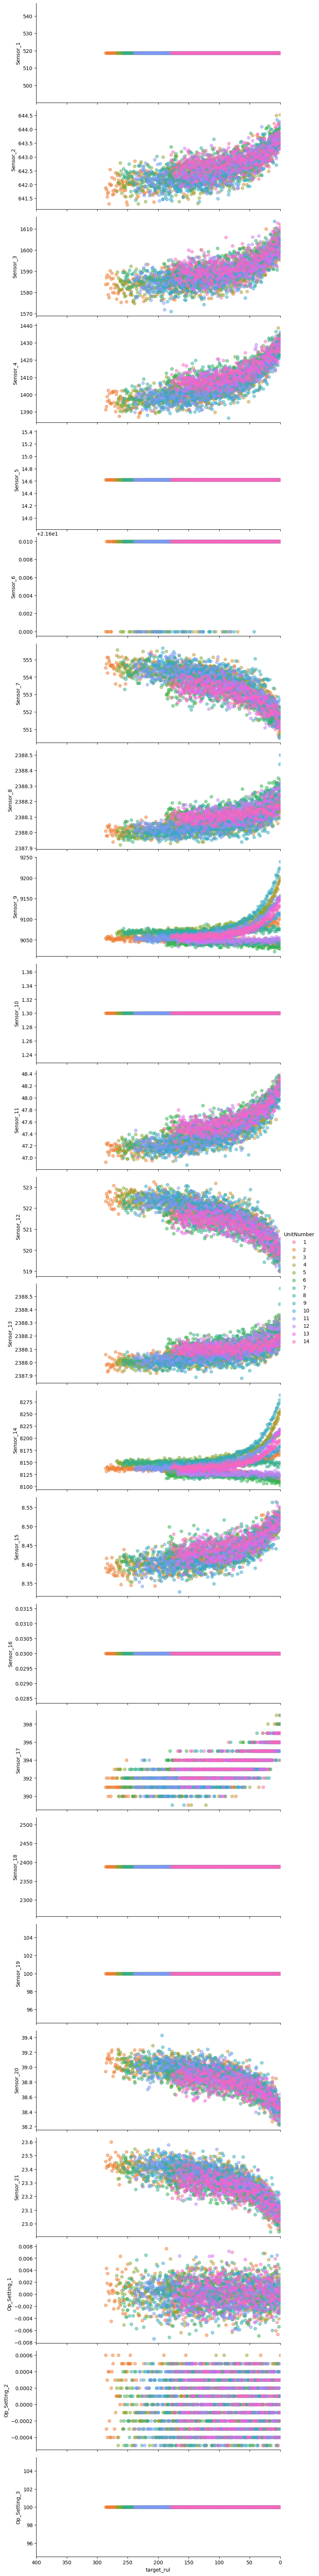

In [14]:
# use seaborn to visualize featuresto target (RUL)
# Create a grid of plots
explore = sns.PairGrid(
    data=train_with_target.query('UnitNumber < 15'),  # filter to first 14 units
    x_vars=target_var,                                # X-axis variables: RUL
    y_vars=sensor_columns + op_settings_columns,      # Y-axis: all sensors and settings
    hue="UnitNumber",                                 # Color code by UnitNumber
    height=3,                                           # Size of each subplot
    aspect=2.5                                        # Stretch each plot horizontally
)

# Plot scatter plots in the grid
explore = explore.map(plt.scatter, alpha=0.5)

# Set X-axis to go from high to low (RUL decreasing like T-minus)
explore = explore.set(xlim=(400,0))

# Add legend for UnitNumbers
explore = explore.add_legend()

In [15]:
train_with_target['Op_Setting_3'].describe()

count    20631.0
mean       100.0
std          0.0
min        100.0
25%        100.0
50%        100.0
75%        100.0
max        100.0
Name: Op_Setting_3, dtype: float64

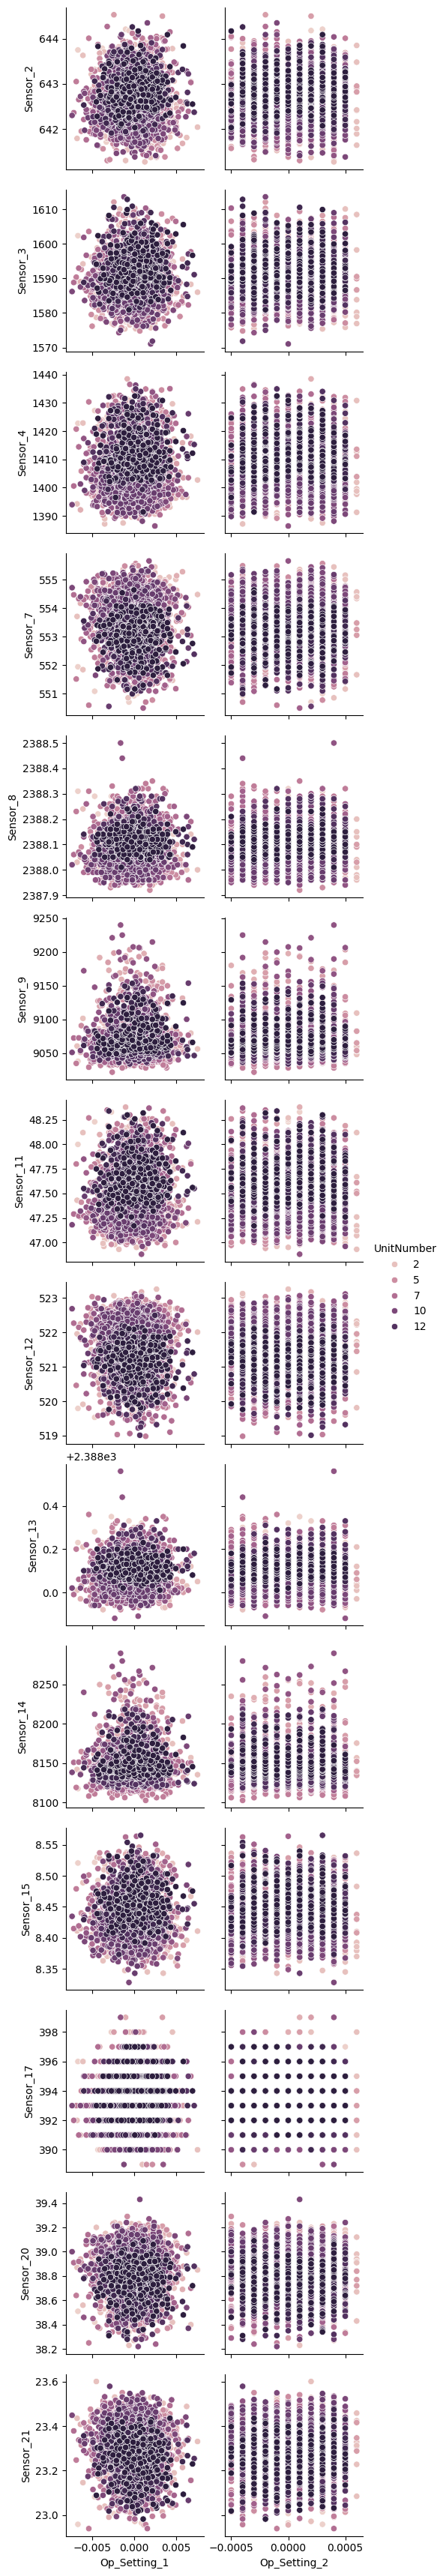

In [16]:
# operational setting 3 is stable, let's visualize op setting 1 and 2 
# against some of the most active sensors
g = sns.pairplot(data=train_with_target.query('UnitNumber < 15'),
                 x_vars=["Op_Setting_1","Op_Setting_2"],
                 y_vars=["Sensor_2", "Sensor_3", "Sensor_4", 
                         "Sensor_7", "Sensor_8", "Sensor_9", 
                         "Sensor_11", "Sensor_12", "Sensor_13", 
                         "Sensor_14", "Sensor_15", "Sensor_17", 
                         "Sensor_20", "Sensor_21"],
                 hue="UnitNumber", aspect=1)

In [17]:
train_with_target.corr()['target_rul'].sort_values(ascending=False)

target_rul      1.000000
Sensor_12       0.671983
Sensor_7        0.657223
Sensor_21       0.635662
Sensor_20       0.629428
UnitNumber      0.078753
Op_Setting_2   -0.001948
Op_Setting_1   -0.003198
Sensor_6       -0.128348
Sensor_14      -0.306769
Sensor_9       -0.390102
Sensor_13      -0.562569
Sensor_8       -0.563968
Sensor_3       -0.584520
Sensor_17      -0.606154
Sensor_2       -0.606484
Sensor_15      -0.642667
Sensor_4       -0.678948
Sensor_11      -0.696228
Cycle          -0.736241
Op_Setting_3         NaN
Sensor_1             NaN
Sensor_5             NaN
Sensor_10            NaN
Sensor_16            NaN
Sensor_18            NaN
Sensor_19            NaN
Name: target_rul, dtype: float64

In [18]:
train_with_target['Op_Setting_3'].min(),train_with_target['Op_Setting_3'].max()

(np.float64(100.0), np.float64(100.0))

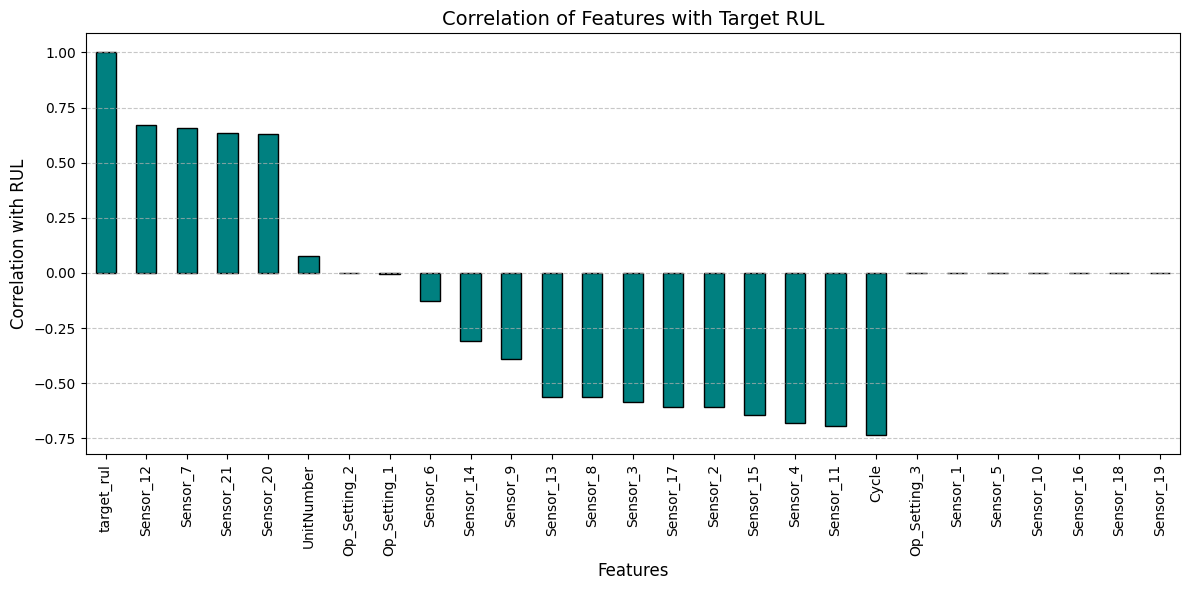

In [19]:
correlation = train_with_target.corr()['target_rul'].sort_values(ascending=False) 

plt.figure(figsize=(12, 6))
correlation.plot(kind='bar', color='teal', edgecolor='black')

plt.title('Correlation of Features with Target RUL', fontsize=14)
plt.xlabel('Features', fontsize=12)
plt.ylabel('Correlation with RUL', fontsize=12)
plt.xticks(rotation=90)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

# Data Preparation

In [20]:
# let's clear out target leakage
leakage_to_drop = ['UnitNumber', 'Cycle', 
                   'Op_Setting_1', 'Op_Setting_2', 'Op_Setting_3']

train_no_leakage = train_with_target.drop(leakage_to_drop, axis = 1)
print(train_no_leakage.shape)

# set up features and target variable 
y = train_no_leakage['target_rul']
X = train_no_leakage.drop(['target_rul'], axis = 1)

(20631, 22)


# Regression

## Model Building

### Random forest algorithm

- combines multiple decision trees,
   - improves accuracy
   - reduce overfitting
   - works well with complex, non-linear relationships
   - provides insights into which features are most influential
- some key points
  - each tree is trained on a **random sample (with replacement)** of the dataset.
  - at **each split** in a tree, **random subset of features** is considered.
- How is prediction made?
  - Classification
    - each tree votes for a class, majority is taken. 
  - Regression
    - average of tree predictions is taken as final output. 

In [21]:
# simple random forest to determine some of the most important/meaningful features
rf = ensemble.RandomForestRegressor()
single_rf = ensemble.RandomForestRegressor(n_estimators = 200, # 200 trees
                                           max_depth = 15)     # can grow to 
                                                               # depth of 15
single_rf.fit(X, y)
y_pred = single_rf.predict(X)

#### Visualize important features

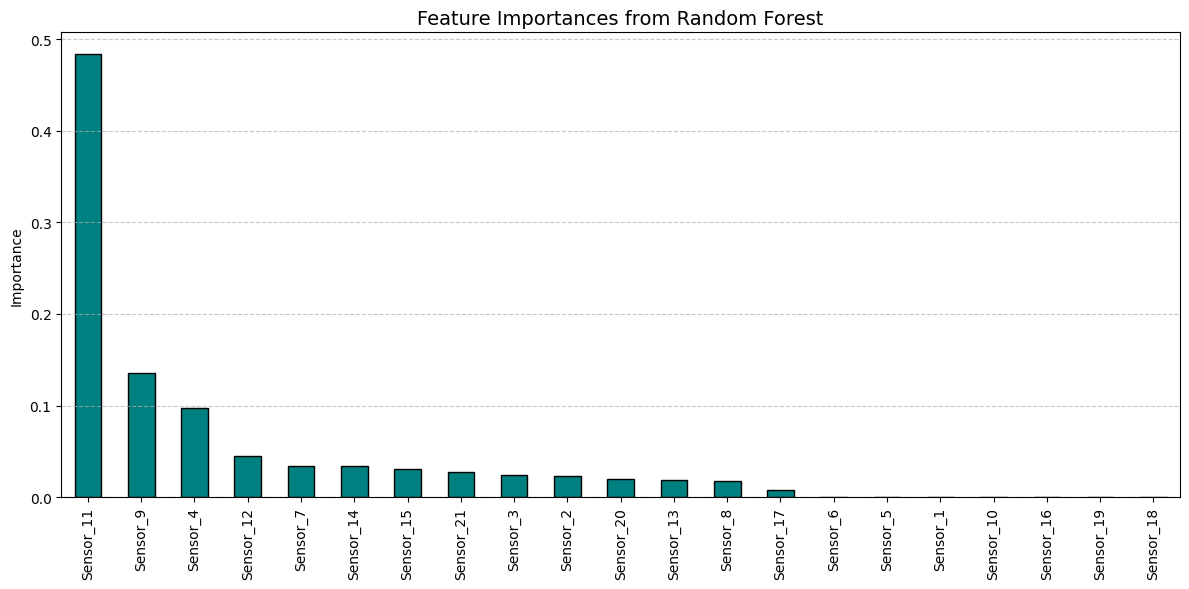

In [22]:
importances = pd.Series(single_rf.feature_importances_, 
                        index=X.columns)
importances_sorted = importances.sort_values(ascending=False)

plt.figure(figsize=(12, 6))
importances_sorted.plot(kind='bar', 
                        color='teal', 
                        edgecolor='black')
plt.title("Feature Importances from Random Forest", 
          fontsize=14)
plt.ylabel("Importance")
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

> Out of all the least important features, except "sensor 6", these were also the sensors with very low correlation with the target variable.

In [23]:
# let's drop some more columns
more_col_drop = ['Sensor_6', 'Sensor_10', 'Sensor_5', 'Sensor_16',
                'Sensor_18', 'Sensor_19', 'Sensor_1']
train_final = train_no_leakage.drop(more_col_drop, axis = 1)

In [24]:
# check null values
print((train_with_target.isnull().mean() * 100).sort_values(ascending=False))

UnitNumber      0.0
Cycle           0.0
Op_Setting_1    0.0
Op_Setting_2    0.0
Op_Setting_3    0.0
Sensor_1        0.0
Sensor_2        0.0
Sensor_3        0.0
Sensor_4        0.0
Sensor_5        0.0
Sensor_6        0.0
Sensor_7        0.0
Sensor_8        0.0
Sensor_9        0.0
Sensor_10       0.0
Sensor_11       0.0
Sensor_12       0.0
Sensor_13       0.0
Sensor_14       0.0
Sensor_15       0.0
Sensor_16       0.0
Sensor_17       0.0
Sensor_18       0.0
Sensor_19       0.0
Sensor_20       0.0
Sensor_21       0.0
target_rul      0.0
dtype: float64


In [25]:
y = train_final['target_rul']
X = train_final.drop(['target_rul'], axis = 1)

#### Training Pipeline for Random Forest

In [26]:
# create holdout
X_train, X_test, y_train, y_test = train_test_split(X, y, 
                                                    test_size=0.2, 
                                                    random_state=1234)

# initialize random forest
rf = ensemble.RandomForestRegressor()

# cross validation
### splits training data into 5 folds.
### Trains on 4 folds, validates on 1 fold — repeats this 5 times.
cv = model_selection.KFold(5)

In [27]:
# create pipeline
### wrapping model and preprocessing in single object by using pipeline
pipeline = Pipeline(steps=[
    ('standardize', StandardScaler()),
    ('model', rf)
]
                   )

# define hyperparameter grid
min_samples_leaf = [2, 10, 25, 50, 100]
max_depth = [7, 8, 9, 10, 11, 12]

# grid search with cross validation
optimized_rf = GridSearchCV(
    estimator=pipeline,
    cv=cv,
    param_grid=dict(
        model__min_samples_leaf=min_samples_leaf,
        model__max_depth=max_depth
    ),
    scoring='neg_mean_squared_error',
    verbose=1,
    n_jobs=-1
)

In [28]:
# training the optimized model
optimized_rf.fit(X_train, y_train)
print(optimized_rf.best_estimator_)

Fitting 5 folds for each of 30 candidates, totalling 150 fits
Pipeline(steps=[('standardize', StandardScaler()),
                ('model',
                 RandomForestRegressor(max_depth=10, min_samples_leaf=10))])


In [29]:
# evaluate on holdout set
y_pred = optimized_rf.predict(X_test)

print("Random Forest Mean Squared Error: ", mean_squared_error(y_test, y_pred))
print("Random Forest Mean Absolute Error: ", mean_absolute_error(y_test, y_pred))
print("Random Forest r-squared: ", r2_score(y_test, y_pred))

Random Forest Mean Squared Error:  1722.8440423863158
Random Forest Mean Absolute Error:  29.643373215455345
Random Forest r-squared:  0.6354679170247961


### Gradient Boosting Regressor

In [30]:
gb = ensemble.GradientBoostingRegressor()

cv = model_selection.KFold(5)
pipeline = Pipeline(steps=[('standardize', StandardScaler())
                           , ('model', gb)
                          ]
                   )

# tune the model
my_alpha = [.5, .75, .9]
my_n_estimators= [500]
my_learning_rate = [0.005, .01]
my_max_depth = [4, 5, 6]

# run the model using gridsearch, select the model with best search
optimized_gb = GridSearchCV(estimator=pipeline,
                            cv=cv,
                            param_grid =dict(model__max_depth = my_max_depth, 
                                             model__n_estimators = my_n_estimators,
                                              model__learning_rate = my_learning_rate, 
                                             model__alpha = my_alpha),
                            scoring = 'neg_mean_squared_error',
                            verbose = 1,
                            n_jobs = -1
                           )
optimized_gb.fit(X_train, y_train)

# show the best model estimators
print(optimized_gb.best_estimator_)

# evaluate metrics on holdout
y_pred = optimized_gb.predict(X_test)
print("Gradient Boosting Mean Squared Error: ", mean_squared_error(y_test, y_pred))
print("Gradient Boosting Mean Absolute Error: ", mean_absolute_error(y_test, y_pred))
print("Gradient Boosting r-squared: ", r2_score(y_test, y_pred))

Fitting 5 folds for each of 18 candidates, totalling 90 fits
Pipeline(steps=[('standardize', StandardScaler()),
                ('model',
                 GradientBoostingRegressor(learning_rate=0.01, max_depth=5,
                                           n_estimators=500))])
Gradient Boosting Mean Squared Error:  1715.232760783863
Gradient Boosting Mean Absolute Error:  29.672167115407984
Gradient Boosting r-squared:  0.6370783682719153


## Visualizing Results

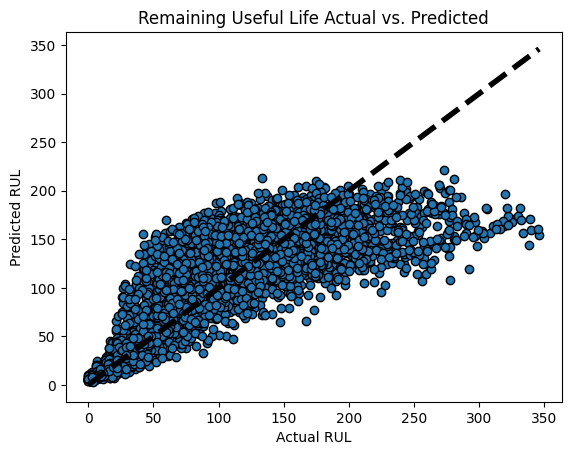

In [31]:
# plot actual vs predicted Remaining Useful Life for the best model (GBM)
fig, ax = plt.subplots()
ax.scatter(y_test, y_pred, edgecolors=(0, 0, 0))
ax.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'k--', lw=4)
ax.set_xlabel('Actual RUL')
ax.set_ylabel('Predicted RUL')
ax.set_title('Remaining Useful Life Actual vs. Predicted')
plt.show()

**Key Points**
> - General Trend Is Good
>   - The points generally follow the dashed diagonal line.
>   - This suggests the model is learning the trend correctly — higher actual RUL corresponds to higher predicted RUL.

> - Underestimation at Higher RUL
>   - For higher actual RUL (>150), the predictions often fall below the dashed line, meaning:
>     - The model tends to underpredict RUL for healthier engines.
>     - It plays conservative — safer in predictive maintenance, but could trigger early interventions (when we have more RUL actually left, but model has predicted lesser RUL left).

> - Good Fit for Lower RUL
>   - When actual RUL is small (say 0–50), predictions are more tightly aligned with the diagonal.
>   - That means the model is good at identifying units nearing failure.

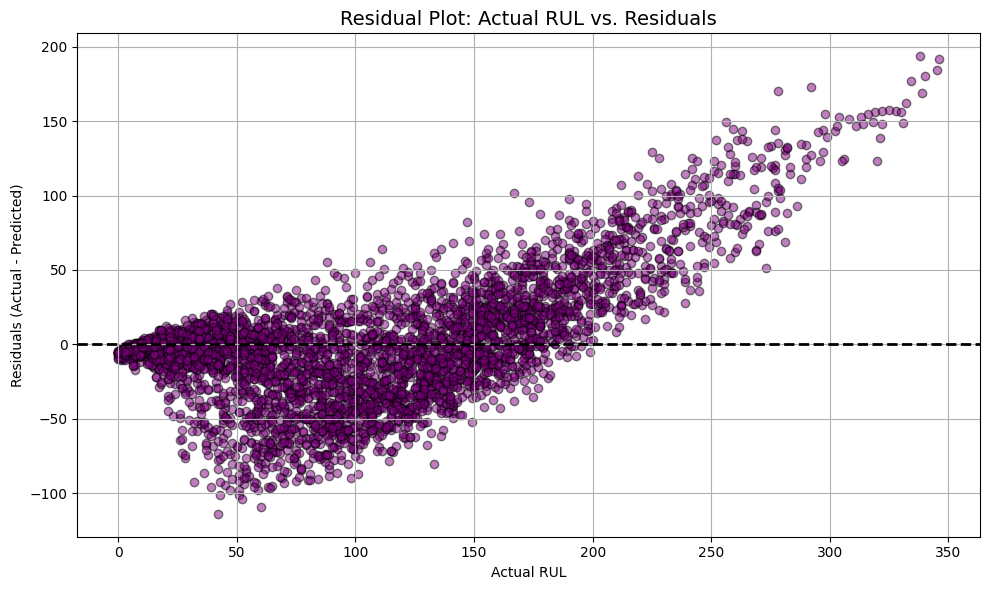

In [32]:
# Compute residuals
residuals = y_test - y_pred

# Scatter plot of residuals vs. actual RUL
plt.figure(figsize=(10, 6))
plt.scatter(y_test, residuals, alpha=0.5, color='purple', edgecolors='k')

# Horizontal line at 0 (perfect prediction)
plt.axhline(y=0, color='black', linestyle='--', linewidth=2)

plt.title('Residual Plot: Actual RUL vs. Residuals', fontsize=14)
plt.xlabel('Actual RUL')
plt.ylabel('Residuals (Actual - Predicted)')
plt.grid(True)
plt.tight_layout()
plt.show()

**Key Points**
> - Residuals are centered around zero for low RUL values (left side of the plot).
> - This means the model is quite accurate when predicting short-term failures, which is critical for predictive maintenance.
> - As RUL increases, residuals move more positively, i.e., Actual > Predicted
>   - This means that model is systematically underpredicting the RUL for components with high actual life remaining.
>   - Increasing spread in residual at higher RUL also shows increasing uncertainty in the model’s predictions for higher RUL values.

## Model Improvement

> - Switch to XGBoost
> - Using a robust loss (pseudohubererror)
> - Weighting high RUL examples

In [33]:
# Sample weights: give more importance to high RUL (last quantile gets more weight)
rul_quantiles = pd.qcut(y_train, q=4, labels=False)
sample_weights = np.where(rul_quantiles >= 2, 2.0, 1.0)  # double weight for top 2 quartiles

# Define XGBoost model
xgb_model = xgb.XGBRegressor(
    objective='reg:pseudohubererror',  # robust loss
    n_jobs=-1,
    verbosity=0,
    random_state=123
)

# Create a pipeline: scale features + model
pipeline = Pipeline(steps=[
    ('scale', StandardScaler()),
    ('model', xgb_model)
])

# Grid search params
param_grid = {
    'model__max_depth': [4, 5, 6],
    'model__n_estimators': [300],
    'model__learning_rate': [0.005, 0.01],
    'model__reg_alpha': [0.1, 1],      # L1 regularization
    'model__reg_lambda': [1, 10]       # L2 regularization
}

# GridSearchCV with KFold
cv = KFold(n_splits=5, shuffle=True, random_state=123)
grid_search = GridSearchCV(
    estimator=pipeline,
    param_grid=param_grid,
    cv=cv,
    scoring='neg_mean_squared_error',
    verbose=1,
    n_jobs=-1
)

# Fit with sample weights
grid_search.fit(X_train, y_train, model__sample_weight=sample_weights)

# Predict on holdout
y_pred = grid_search.predict(X_test)

# Evaluate
print("Best model:", grid_search.best_estimator_)
print("XGBoost MSE:", mean_squared_error(y_test, y_pred))
print("XGBoost MAE:", mean_absolute_error(y_test, y_pred))
print("XGBoost R2:", r2_score(y_test, y_pred))

Fitting 5 folds for each of 24 candidates, totalling 120 fits
Best model: Pipeline(steps=[('scale', StandardScaler()),
                ('model',
                 XGBRegressor(base_score=None, booster=None, callbacks=None,
                              colsample_bylevel=None, colsample_bynode=None,
                              colsample_bytree=None, device=None,
                              early_stopping_rounds=None,
                              enable_categorical=False, eval_metric=None,
                              feature_types=None, gamma=None, grow_policy=None,
                              importance_type=None,
                              interaction_constraints=None, learning_rate=0.01,
                              max_bin=None, max_cat_threshold=None,
                              max_cat_to_onehot=None, max_delta_step=None,
                              max_depth=6, max_leaves=None,
                              min_child_weight=None, missing=nan,
                      

> - log transformation

In [34]:
# --- Apply log1p transformation to the target ---
y_train_transformed = np.log1p(y_train)

# --- Sample weights: more weight to higher RUL values ---
rul_quantiles = pd.qcut(y_train, q=4, labels=False)
sample_weights = np.where(rul_quantiles >= 2, 2.0, 1.0)

# --- Scale features manually ---
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


# --- Define XGBoost model ---
xgb_model = xgb.XGBRegressor(
    objective='reg:squarederror',
    n_jobs=-1,
    verbosity=0,
    random_state=123
)

# --- Grid search hyperparameters ---
param_grid = {
    'max_depth': [4, 5, 6],
    'n_estimators': [300],
    'learning_rate': [0.005, 0.01],
    'reg_alpha': [0.1, 1],      # L1 regularization
    'reg_lambda': [1, 10]       # L2 regularization
}

# --- 5-fold cross-validation ---
cv = KFold(n_splits=5, shuffle=True, random_state=123)

# --- GridSearch with sample_weight ---
grid_search = GridSearchCV(
    estimator=xgb_model,
    param_grid=param_grid,
    cv=cv,
    scoring='neg_mean_squared_error',
    verbose=1,
    n_jobs=-1
)

# --- Fit the model with sample weights ---
grid_search.fit(X_train_scaled, 
                y_train_transformed, 
                sample_weight=sample_weights)

# --- Predict and inverse log transform ---
y_pred_log = grid_search.predict(X_test_scaled)
y_pred = np.expm1(y_pred_log)  # Inverse of log1p to get back to original scale

# --- Evaluate against raw y_test ---
print("Best estimator:\n", grid_search.best_estimator_)
print("\n Metrics on original RUL scale:")
print("MSE:", mean_squared_error(y_test, y_pred))
print("MAE:", mean_absolute_error(y_test, y_pred))
print("R2 Score:", r2_score(y_test, y_pred))

Fitting 5 folds for each of 24 candidates, totalling 120 fits
Best estimator:
 XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             gamma=None, grow_policy=None, importance_type=None,
             interaction_constraints=None, learning_rate=0.01, max_bin=None,
             max_cat_threshold=None, max_cat_to_onehot=None,
             max_delta_step=None, max_depth=6, max_leaves=None,
             min_child_weight=None, missing=nan, monotone_constraints=None,
             multi_strategy=None, n_estimators=300, n_jobs=-1,
             num_parallel_tree=None, random_state=123, ...)

 Metrics on original RUL scale:
MSE: 1754.6874014166272
MAE: 29.644554772185217
R2 Score: 0.628730297088623


# Classification

> Let's see if we can confidently identify when an asset is going to fail within its last 15 cycles?

In [35]:
cycles = 15
train_no_leakage['Target_15_Cycles'] = np.where(train_no_leakage['target_rul'] <= cycles, 
                                                1, 
                                                0)

In [36]:
train_no_leakage

,Sensor_1,Sensor_2,Sensor_3,Sensor_4,Sensor_5,Sensor_6,Sensor_7,Sensor_8,Sensor_9,Sensor_10,...,Sensor_14,Sensor_15,Sensor_16,Sensor_17,Sensor_18,Sensor_19,Sensor_20,Sensor_21,target_rul,Target_15_Cycles
0,518.67,641.82,1589.70,1400.60,14.62,21.61,554.36,2388.06,9046.19,1.3,...,8138.62,8.4195,0.03,392,2388,100.0,39.06,23.4190,191,0
1,518.67,642.15,1591.82,1403.14,14.62,21.61,553.75,2388.04,9044.07,1.3,...,8131.49,8.4318,0.03,392,2388,100.0,39.00,23.4236,190,0
2,518.67,642.35,1587.99,1404.20,14.62,21.61,554.26,2388.08,9052.94,1.3,...,8133.23,8.4178,0.03,390,2388,100.0,38.95,23.3442,189,0
3,518.67,642.35,1582.79,1401.87,14.62,21.61,554.45,2388.11,9049.48,1.3,...,8133.83,8.3682,0.03,392,2388,100.0,38.88,23.3739,188,0
4,518.67,642.37,1582.85,1406.22,14.62,21.61,554.00,2388.06,9055.15,1.3,...,8133.80,8.4294,0.03,393,2388,100.0,38.90,23.4044,187,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
20626,518.67,643.49,1597.98,1428.63,14.62,21.61,551.43,2388.19,9065.52,1.3,...,8137.60,8.4956,0.03,397,2388,100.0,38.49,22.9735,4,1
20627,518.67,643.54,1604.50,1433.58,14.62,21.61,550.86,2388.23,9065.11,1.3,...,8136.50,8.5139,0.03,395,2388,100.0,38.30,23.1594,3,1
20628,518.67,643.42,1602.46,1428.18,14.62,21.61,550.94,2388.24,9065.90,1.3,...,8141.05,8.5646,0.03,398,2388,100.0,38.44,22.9333,2,1
20629,518.67,643.23,1605.26,1426.53,14.62,21.61,550.68,2388.25,9073.72,1.3,...,8139.29,8.5389,0.03,395,2388,100.0,38.29,23.0640,1,1


In [37]:
# let's drop some more columns
more_col_drop = ['Sensor_6', 'Sensor_10', 'Sensor_5', 'Sensor_16',
                'Sensor_18', 'Sensor_19', 'Sensor_1']
train_final = train_no_leakage.drop(more_col_drop, axis = 1)

In [38]:
train_final.drop('target_rul', axis=1, inplace=True)

## Make X, y dataframes

In [39]:
y = train_final['Target_15_Cycles'].copy()
X = train_final.drop(['Target_15_Cycles'], axis = 1).copy()

## Model Building

In [40]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=1234)

rf = ensemble.RandomForestClassifier()

# set up 5-fold cross-validation
cv = model_selection.KFold(5)

# pipeline standardization and model
pipeline = Pipeline(steps=[('standardize', StandardScaler())
                           , ('model', rf) ])

# tune the model
my_min_samples_leaf = [2, 25, 50]
my_max_depth = [8, 9, 10, 12]

# run the model using gridsearch, select the model with best search
optimized_rf = GridSearchCV(estimator=pipeline,
                            cv=cv,
                            param_grid =dict(model__min_samples_leaf = my_min_samples_leaf, 
                                             model__max_depth = my_max_depth),
                            scoring = 'roc_auc',
                            verbose = 1,
                            n_jobs = -1
                           )

optimized_rf.fit(X_train, y_train)

# show the best model estimators
y_pred_proba = optimized_rf.predict_proba(X_test)[:, 1]
y_pred = optimized_rf.predict(X_test)
print(optimized_rf.best_estimator_)

Fitting 5 folds for each of 12 candidates, totalling 60 fits
Pipeline(steps=[('standardize', StandardScaler()),
                ('model',
                 RandomForestClassifier(max_depth=8, min_samples_leaf=2))])


## Evaluation

In [41]:
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))

Confusion Matrix:
[[3786   56]
 [  39  246]]


In [42]:
print("Random Forest Accuracy: "+"{:.1%}".format(accuracy_score(y_test, y_pred)));
print("Random Forest Precision: "+"{:.1%}".format(precision_score(y_test, y_pred)));
print("Random Forest Recall: "+"{:.1%}".format(recall_score(y_test, y_pred)));

Random Forest Accuracy: 97.7%
Random Forest Precision: 81.5%
Random Forest Recall: 86.3%


AUC will plot,
- True Positive Rate (TPR) = Sensitivity / Recall
  - How many actual positives your model correctly identifies
- False Positive Rate (FPR)
  - How many actual negatives your model incorrectly classifies as positive

**Intuition**
> At different classification thresholds (e.g., 0.2, 0.5, 0.8), a model makes different trade-offs between:
> - Catching more failures (TPR ↑)
> - Making fewer false alarms (FPR ↓)

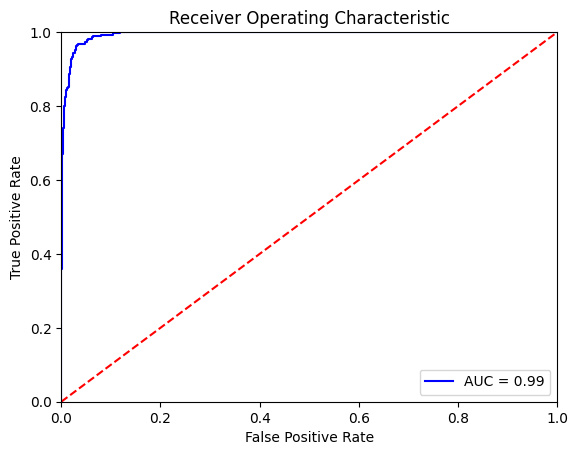

In [43]:
fpr, tpr, threshold = roc_curve(y_test, y_pred_proba)
roc_auc = auc(fpr, tpr)

plt.title('Receiver Operating Characteristic')
plt.plot(fpr, tpr, 'b', label = 'AUC = %0.2f' % roc_auc)
plt.legend(loc = 'lower right')
plt.plot([0, 1], [0, 1],'r--')
plt.xlim([0, 1])
plt.ylim([0, 1])
plt.ylabel('True Positive Rate')
plt.xlabel('False Positive Rate')
plt.show()